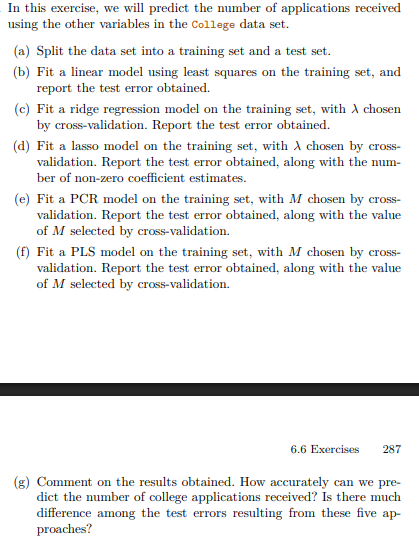

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from ISLP import load_data

College = load_data("College")
X = College.drop(columns="Apps")
y = College['Apps']

#Encoding independent variables
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 1)

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

regressor = LinearRegression()
model = regressor.fit(X_train, y_train)
y_pred_lm = model.predict(X_test)
mse_lm = mean_squared_error(y_test, y_pred_lm)

print("Linear regression test MSE:", round(mse_lm, 2))

Linear regression test MSE: 640045.03


In [8]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

alphas = np.logspace(-3, 3, 100)
ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=10))
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print("Chosen lambda (alpha):", ridge.named_steps['ridgecv'].alpha_)
print("Ridge regression test MSE:", round(mse_ridge, 2))

Chosen lambda (alpha): 8.697490026177835
Ridge regression test MSE: 675257.43


In [9]:
from sklearn.linear_model import LassoCV

lasso = make_pipeline(StandardScaler(), LassoCV(cv=10, random_state=42, max_iter=10000))
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

# Count non-zero coefficients
lasso_model = lasso.named_steps['lassocv']
nonzero_count = np.sum(lasso_model.coef_ != 0)

print("Chosen lambda (alpha):", lasso_model.alpha_)
print("Lasso regression test MSE:", round(mse_lasso, 2))
print("Number of non-zero coefficients:", nonzero_count)

Chosen lambda (alpha): 11.972571922448246
Lasso regression test MSE: 684304.18
Number of non-zero coefficients: 15


In [10]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Standardize features
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Try PCR with 1 to max components
max_components = X_train.shape[1]
mse_list = []

for m in range(1, max_components + 1):
    pca = PCA(n_components=m)
    X_train_pca = pca.fit_transform(X_train_scaled)
    scores = cross_val_score(LinearRegression(), X_train_pca, y_train, cv=10, scoring='neg_mean_squared_error')
    mse_list.append(-scores.mean())

# Select best M
best_m = np.argmin(mse_list) + 1
print("PCR selected M =", best_m)

# Fit PCR model with best M
pca_final = PCA(n_components=best_m).fit(X_train_scaled)
X_train_pca = pca_final.transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

lm_pcr = LinearRegression().fit(X_train_pca, y_train)
y_pred_pcr = lm_pcr.predict(X_test_pca)
mse_pcr = mean_squared_error(y_test, y_pred_pcr)

print("PCR test MSE:", round(mse_pcr, 2))

PCR selected M = 17
PCR test MSE: 640045.03
